# Máquina de Vectores de Soporte (SVM) — Sistemas Basados en Conocimiento

**Autor:** Víctor Vargas Miranda  
**Dataset:** [Wine Dataset — Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html)  
**Librería principal:** [Scikit-Learn](https://scikit-learn.org/stable/install)

---

## 1. ¿Qué problema resuelve la Máquina de Vectores de Soporte (SVM)?

La **Máquina de Vectores de Soporte** (*Support Vector Machine*, SVM) es un algoritmo de aprendizaje supervisado que resuelve principalmente problemas de **clasificación**, aunque también puede adaptarse para **regresión** (SVR) y **detección de anomalías**.

La idea central es encontrar el **hiperplano óptimo** que separa las clases en el espacio de características, maximizando el **margen** entre los puntos más cercanos de cada clase (llamados **vectores de soporte**). Esto lo distingue de otros clasificadores que simplemente buscan cualquier frontera de decisión que separe los datos.

### Intuición geométrica

Imagina que tienes puntos de dos clases en un plano 2D. SVM busca la línea (hiperplano en 2D) que:
1. Separa correctamente las dos clases.
2. Mantiene la mayor distancia posible entre la línea y los puntos más cercanos de cada clase.

Cuando los datos no son linealmente separables en el espacio original, SVM utiliza el **truco del kernel** (*kernel trick*) para proyectarlos implícitamente a un espacio de mayor dimensión donde sí puedan separarse.

### Formulación matemática básica

Para clasificación binaria, dado un conjunto de entrenamiento $\{(\mathbf{x}_i, y_i)\}$, donde $y_i \in \{-1, +1\}$, SVM resuelve el siguiente problema de optimización:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i$$

sujeto a: $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i$ y $\xi_i \geq 0$

Donde $\mathbf{w}$ es el vector normal al hiperplano, $b$ es el sesgo, $\xi_i$ son variables de holgura (*slack variables*) que permiten cierta clasificación incorrecta, y $C$ es el hiperparámetro de regularización.

Para clasificación multiclase (como el caso del dataset Wine con 3 clases), scikit-learn utiliza por defecto la estrategia **OvO** (*One-vs-One*), donde se entrenan $\frac{k(k-1)}{2}$ clasificadores binarios y se escoge la clase más votada.

## 2. Supuestos Fundamentales del Modelo

El algoritmo SVM parte de los siguientes supuestos y condiciones:

1. **Separabilidad (o casi-separabilidad):** Los datos deben ser separables en el espacio de características original o en algún espacio transformado mediante un kernel. La versión de margen blando (*soft margin*, controlado por el parámetro $C$) relaja este supuesto permitiendo algunas clasificaciones incorrectas.

2. **Linealidad en el espacio del kernel:** Aunque los datos originales pueden ser no lineales, SVM asume que existe un mapeo (implícito mediante el kernel) que los hace linealmente separables. La elección del kernel correcto es crucial.

3. **Independencia de las observaciones:** Las muestras deben ser independientes entre sí. SVM no modela dependencias temporales ni espaciales por sí solo.

4. **Datos numéricos:** SVM opera sobre espacios vectoriales, por lo que las variables categóricas deben codificarse numéricamente (e.g., *one-hot encoding*).

5. **Escala de las variables:** SVM es sensible a la escala de las características. Es imprescindible **normalizar o estandarizar** los datos antes de entrenar, ya que características en rangos muy diferentes pueden dominar el cálculo de distancias.

### Tipos de Kernels comunes

| Kernel | Fórmula | Cuándo usarlo |
|--------|---------|---------------|
| Lineal | $K(\mathbf{x}, \mathbf{z}) = \mathbf{x}^\top\mathbf{z}$ | Datos linealmente separables o alta dimensionalidad |
| Polinomial | $K(\mathbf{x}, \mathbf{z}) = (\gamma \mathbf{x}^\top\mathbf{z} + r)^d$ | Relaciones polinomiales entre variables |
| RBF (Gaussiano) | $K(\mathbf{x}, \mathbf{z}) = e^{-\gamma\|\mathbf{x}-\mathbf{z}\|^2}$ | Datos no lineales, caso general |
| Sigmoide | $K(\mathbf{x}, \mathbf{z}) = \tanh(\gamma \mathbf{x}^\top\mathbf{z} + r)$ | Alternativa a redes neuronales simples |

## 3. Usos y Aplicaciones Potenciales

SVM es uno de los algoritmos más versátiles en aprendizaje automático clásico. Sus aplicaciones abarcan múltiples dominios:

| Dominio | Aplicación |
|---------|------------|
| **Bioinformática** | Clasificación de proteínas, diagnóstico de enfermedades a partir de datos genómicos |
| **Visión por computadora** | Reconocimiento facial, clasificación de imágenes, detección de objetos |
| **Procesamiento de texto** | Clasificación de documentos, análisis de sentimientos, detección de spam |
| **Medicina** | Diagnóstico de cáncer a partir de imágenes médicas o biomarcadores |
| **Finanzas** | Detección de fraudes, clasificación de riesgo crediticio |
| **Industria** | Detección de anomalías en procesos de manufactura (One-Class SVM) |
| **Control de calidad** | Clasificación de productos defectuosos |

En el contexto del presente notebook, aplicamos SVM para **clasificar vinos** en tres categorías según sus propiedades químicas, un problema típico en enología computacional.

## 4. ¿En Qué Tipos de Problemas es Apropiado?

SVM es especialmente apropiado en los siguientes escenarios:

- **Clasificación con margen claro entre clases:** Cuando las clases son relativamente separables y existe un margen bien definido entre ellas.

- **Espacios de alta dimensionalidad:** SVM funciona bien cuando el número de características es grande (incluso mayor que el número de muestras), como en clasificación de texto donde cada palabra es una característica.

- **Conjuntos de datos de tamaño pequeño a mediano:** A diferencia de redes neuronales profundas, SVM puede obtener buenos resultados con pocos datos de entrenamiento, ya que su decisión depende solo de los vectores de soporte.

- **Problemas con frontera de decisión no lineal:** Utilizando kernels no lineales (RBF, polinomial), SVM puede capturar patrones complejos.

- **Detección de anomalías (One-Class SVM):** Cuando solo se dispone de datos de una clase ("normal") y se desea detectar instancias anómalas.

### Cuándo NO es apropiado

- Datasets muy grandes (>100,000 muestras): el tiempo de entrenamiento crece cuadráticamente o cúbicamente con el número de muestras.
- Cuando se requieren probabilidades calibradas de forma nativa (aunque `probability=True` lo aproxima con validación cruzada Platt).
- Datos con mucho ruido o fuerte superposición de clases.

## 5. ¿Cuándo es Preferible Frente a Modelos Más Complejos?

SVM puede ser preferible a modelos más sofisticados como redes neuronales profundas, Random Forests o Gradient Boosting en las siguientes situaciones:

| Situación | Por qué SVM es preferible |
|-----------|---------------------------|
| **Datos escasos** | SVM generaliza bien con pocas muestras; las redes neuronales necesitan miles de ejemplos |
| **Alta dimensionalidad** | Con muchas características y pocas muestras, SVM evita el sobreajuste mejor que métodos de ensamble |
| **Interpretación del margen** | El concepto de margen máximo es matemáticamente fundamentado y teóricamente garantiza mejor generalización |
| **Recursos computacionales limitados** | Para inferencia, SVM requiere solo evaluar los vectores de soporte, lo cual puede ser más rápido que árboles con muchos nodos |
| **Requisitos de regularización estrictos** | El parámetro $C$ y el kernel ofrecen control preciso sobre la complejidad del modelo |

**Cuándo elegir modelos más complejos:**
- Cuando hay decenas de miles de muestras (Random Forest o XGBoost escalan mejor).
- Cuando los datos son imágenes, audio o texto en bruto sin extracción de características manual (redes neuronales profundas).
- Cuando se necesita manejar automáticamente características categóricas con alta cardinalidad.

## 6. Pros y Contras desde la Perspectiva de la Explicabilidad (XAI)

La **Inteligencia Artificial Explicable (XAI)** busca que los modelos de ML sean comprensibles para los humanos. Veamos cómo se posiciona SVM en este marco:

### ✅ Pros de SVM desde XAI

1. **Kernel lineal = coeficientes interpretables:** Con kernel lineal, el vector $\mathbf{w}$ actúa como los coeficientes de regresión: valores altos (en magnitud) indican características más influyentes.

2. **Vectores de soporte identificables:** Los vectores de soporte son los puntos más informativos del modelo; pueden inspeccionarse directamente para entender qué instancias definen la frontera de decisión.

3. **Base matemática sólida:** El principio de maximización del margen tiene una justificación teórica clara (teoría de aprendizaje estadístico VC), lo cual facilita comunicar el "por qué" del modelo.

4. **Sensibilidad local conocida:** Las predicciones solo dependen de los vectores de soporte, lo que reduce la complejidad de la explicación local.

### ❌ Contras de SVM desde XAI

1. **Kernel no lineal = caja negra:** Con kernels RBF o polinomial, la frontera de decisión en el espacio original es muy difícil de interpretar directamente.

2. **No genera probabilidades directamente:** SVM produce una distancia al hiperplano, no una probabilidad. La calibración de Platt (`probability=True`) añade interpretabilidad probabilística pero con costo computacional.

3. **Importancia de variables no directa:** A diferencia de árboles de decisión, SVM no provee una medida directa de importancia de variables para kernels no lineales.

4. **Difícil comunicar a no-técnicos:** Conceptos como hiperplano, margen y kernel son difíciles de explicar a usuarios sin formación matemática.

### Técnicas XAI compatibles con SVM

| Técnica | Descripción |
|---------|-------------|
| **SHAP** | Calcula contribuciones de cada feature a la predicción (compatible con SVM mediante kernelExplainer) |
| **LIME** | Aproxima localmente el modelo con uno lineal interpretable |
| **Permutation Importance** | Mide el impacto de permutar cada variable en el rendimiento del modelo |
| **Coeficientes del kernel lineal** | Directamente interpretables como importancia de variables (solo kernel lineal) |

---
## 7. Solución Técnica: Clasificación de Vinos con SVM

### 7.1 Descripción del Problema

**¿Qué se predice?** La **variedad de vino** (clase 0, 1 o 2) a partir de 13 propiedades químicas medidas en laboratorio.

**¿Por qué es importante?** La clasificación automática de vinos a partir de análisis químico tiene aplicaciones en control de calidad enológico, certificación de origen y detección de adulteración. Es un problema de clasificación multiclase con características continuas, ideal para demostrar SVM.

**Dataset:** [Wine Dataset de Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html), que contiene 178 muestras de vinos italianos provenientes de tres cultivares diferentes, con 13 atributos químicos medidos para cada muestra.

### 7.2 Carga del Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

# Configuración de estilo de gráficos
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# Carga del dataset Wine (referencia: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html)
data = load_wine()

# Verificación de las clases según el enunciado
print('Muestra de etiquetas de clase:')
print('Índices [10, 80, 140]:', data.target[[10, 80, 140]])
print('Nombres de clases:', list(data.target_names))
print()
print('Descripción del dataset:')
print(f'  Número de muestras: {data.data.shape[0]}')
print(f'  Número de características: {data.data.shape[1]}')
print(f'  Características: {data.feature_names}')
print(f'  Clases: {data.target_names}')

Muestra de etiquetas de clase:
Índices [10, 80, 140]: [0 1 2]
Nombres de clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Descripción del dataset:
  Número de muestras: 178
  Número de características: 13
  Características: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
  Clases: ['class_0' 'class_1' 'class_2']


In [3]:
# Crear DataFrame para análisis exploratorio
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['class_name'] = [data.target_names[t] for t in data.target]

print('Primeras 5 filas del dataset:')
df.head()

Primeras 5 filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


### 7.3 Análisis Exploratorio y Limpieza de Datos

El dataset Wine de Scikit-Learn es un dataset de referencia ya limpio y preprocesado. Verificaremos la ausencia de valores nulos y la distribución de clases.

In [4]:
# Verificación de valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Distribución de clases:')
print(df['class_name'].value_counts())

Valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
class_name                      0
dtype: int64

Distribución de clases:
class_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [5]:
# Estadísticas descriptivas
print('Estadísticas descriptivas de las características:')
df.drop(columns=['target', 'class_name']).describe().round(2)

Estadísticas descriptivas de las características:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


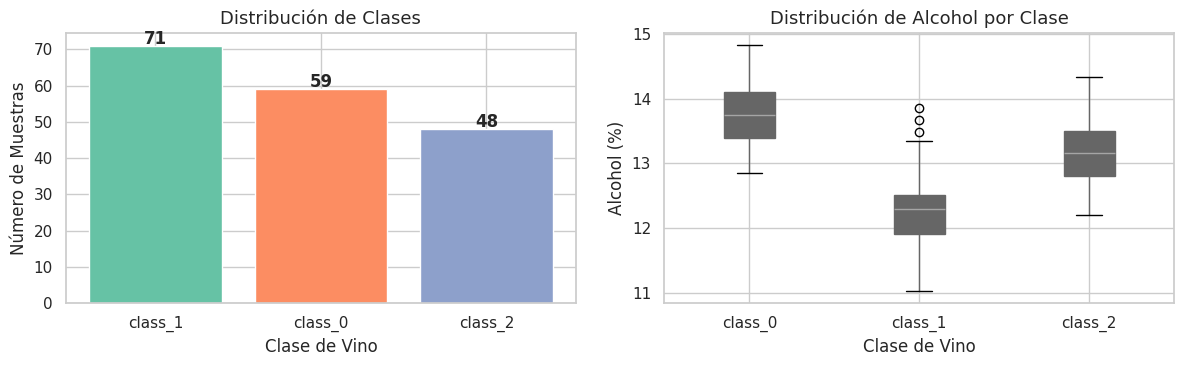

In [6]:
# Visualización de la distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras de distribución de clases
class_counts = df['class_name'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['#66c2a5', '#fc8d62', '#8da0cb'])
axes[0].set_title('Distribución de Clases', fontsize=13)
axes[0].set_xlabel('Clase de Vino')
axes[0].set_ylabel('Número de Muestras')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Boxplot de dos características importantes por clase
df.boxplot(column='alcohol', by='class_name', ax=axes[1], patch_artist=True)
axes[1].set_title('Distribución de Alcohol por Clase', fontsize=13)
axes[1].set_xlabel('Clase de Vino')
axes[1].set_ylabel('Alcohol (%)')
plt.suptitle('')

plt.tight_layout()
plt.show()

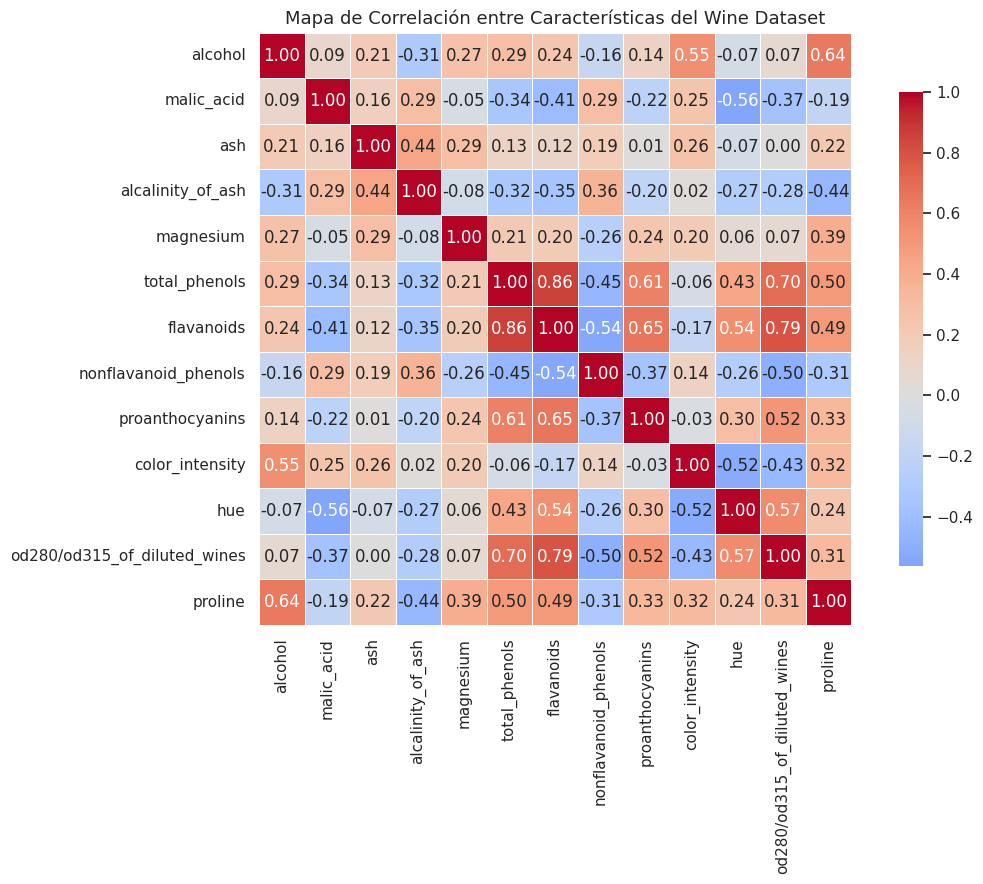

In [7]:
# Mapa de correlación entre características
plt.figure(figsize=(12, 9))
corr_matrix = df.drop(columns=['target', 'class_name']).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Mapa de Correlación entre Características del Wine Dataset', fontsize=13)
plt.tight_layout()
plt.show()

**Observaciones del análisis exploratorio:**

- El dataset está **balanceado** con 59 muestras de class_0, 71 de class_1 y 48 de class_2, lo que evita sesgos por desbalanceo.
- **No hay valores nulos**, por lo que no se requiere limpieza de datos.
- Las características tienen **escalas muy diferentes** (e.g., `proline` va de ~278 a ~1680, mientras que `nonflavanoid_phenols` va de ~0.1 a ~0.7). Esto hace **imprescindible la estandarización** antes de aplicar SVM.
- Se observan correlaciones moderadas a fuertes entre algunas características (e.g., `total_phenols` y `flavanoids`).

### 7.4 Selección de Variables

Utilizaremos **todas las 13 características** disponibles del dataset, ya que:
1. El número de características es manejable para SVM.
2. No hay evidencia de multicolinealidad extrema que justifique eliminación.
3. SVM con kernel RBF puede manejar internamente el peso relativo de cada variable en el espacio transformado.

Se incluirá un análisis de importancia de variables post-entrenamiento mediante **Permutation Importance**.

In [8]:
# Separación de características (X) y etiquetas (y)
X = data.data
y = data.target

feature_names = data.feature_names
class_names = data.target_names

print(f'Forma de X: {X.shape}  →  {X.shape[0]} muestras, {X.shape[1]} características')
print(f'Forma de y: {y.shape}')
print(f'Clases: {class_names}')

Forma de X: (178, 13)  →  178 muestras, 13 características
Forma de y: (178,)
Clases: ['class_0' 'class_1' 'class_2']


### 7.5 Separación en Conjuntos de Entrenamiento y Prueba

In [9]:
# División estratificada: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Mantiene proporción de clases en ambos subconjuntos
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de prueba:        {X_test.shape[0]} muestras')
print()
print('Distribución de clases en entrenamiento:', np.bincount(y_train))
print('Distribución de clases en prueba:       ', np.bincount(y_test))

Conjunto de entrenamiento: 142 muestras
Conjunto de prueba:        36 muestras

Distribución de clases en entrenamiento: [47 57 38]
Distribución de clases en prueba:        [12 14 10]


### 7.6 Preprocesamiento: Estandarización

SVM es **sensible a la escala** de las variables. Aplicamos `StandardScaler` que transforma cada característica para tener media 0 y desviación estándar 1:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

> **Importante:** El scaler se ajusta **solo en los datos de entrenamiento** (`fit_transform`) y se aplica a los datos de prueba (`transform`) para evitar *data leakage*.

In [10]:
# Estandarización de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Ajusta y transforma entrenamiento
X_test_scaled = scaler.transform(X_test)         # Solo transforma prueba

print('Estadísticas post-estandarización (entrenamiento):')
print(f'  Media de características: {X_train_scaled.mean(axis=0).round(4)}')
print(f'  Std de características:   {X_train_scaled.std(axis=0).round(4)}')

Estadísticas post-estandarización (entrenamiento):
  Media de características: [ 0. -0.  0.  0.  0. -0.  0. -0. -0.  0. -0.  0. -0.]
  Std de características:   [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 7.7 Implementación del Algoritmo SVM con Scikit-Learn

Utilizamos `SVC` (*Support Vector Classifier*) de Scikit-Learn. Comenzamos con un modelo de **kernel RBF** (el más utilizado en problemas de clasificación general), y luego optimizamos los hiperparámetros.

**Hiperparámetros principales de `SVC`:**
- `C`: Parámetro de regularización. Valores altos → menor margen, menor error en entrenamiento (riesgo de sobreajuste). Valores bajos → mayor margen, más errores tolerados.
- `gamma`: Parámetro del kernel RBF. Controla el alcance de influencia de cada punto. `'scale'` usa $1/(n\_features \times X.var())$.
- `kernel`: Tipo de kernel (`'linear'`, `'rbf'`, `'poly'`, `'sigmoid'`).

In [11]:
# Modelo SVM con kernel RBF (configuración inicial)
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    probability=True  # Habilita estimación de probabilidades (método de Platt)
)

print('Configuración del modelo SVM:')
print(svm_model)

Configuración del modelo SVM:
SVC(probability=True, random_state=42)


### 7.8 Búsqueda de Hiperparámetros con GridSearchCV

Optimizamos los hiperparámetros `C` y `gamma` mediante validación cruzada (5-fold), evaluando el accuracy como métrica de selección.

In [12]:
# Grilla de hiperparámetros a explorar
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Búsqueda de mejores hiperparámetros con validación cruzada estratificada de 5 folds
grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f'\nMejores hiperparámetros encontrados: {grid_search.best_params_}')
print(f'Mejor accuracy en validación cruzada: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits



Mejores hiperparámetros encontrados: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mejor accuracy en validación cruzada: 0.9862


### 7.9 Ajuste del Modelo Óptimo a los Datos

In [13]:
# Usar el mejor modelo encontrado por GridSearchCV
best_svm = grid_search.best_estimator_

print(f'Modelo óptimo entrenado: {best_svm}')
print()

# Información sobre los vectores de soporte
print('Información sobre Vectores de Soporte:')
print(f'  Total de vectores de soporte: {best_svm.n_support_.sum()}')
print(f'  Vectores de soporte por clase: {best_svm.n_support_}')
print(f'  (class_0: {best_svm.n_support_[0]}, class_1: {best_svm.n_support_[1]}, class_2: {best_svm.n_support_[2]})')

Modelo óptimo entrenado: SVC(C=0.1, kernel='linear', probability=True, random_state=42)

Información sobre Vectores de Soporte:
  Total de vectores de soporte: 37
  Vectores de soporte por clase: [10 15 12]
  (class_0: 10, class_1: 15, class_2: 12)


### 7.10 Evaluación del Modelo con Métricas Apropiadas

In [14]:
# Predicciones sobre el conjunto de prueba
y_pred = best_svm.predict(X_test_scaled)
y_prob = best_svm.predict_proba(X_test_scaled)

# Métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f'=== MÉTRICAS DE EVALUACIÓN ===')
print(f'Accuracy en conjunto de prueba: {accuracy:.4f} ({accuracy*100:.2f}%)')
print()
print('Reporte de Clasificación por Clase:')
print(classification_report(y_test, y_pred, target_names=class_names))

=== MÉTRICAS DE EVALUACIÓN ===
Accuracy en conjunto de prueba: 0.9722 (97.22%)

Reporte de Clasificación por Clase:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [15]:
# Validación cruzada del modelo óptimo sobre todos los datos
X_all_scaled = scaler.fit_transform(X)  # Re-escalar todo el dataset
cv_scores = cross_val_score(best_svm, X_all_scaled, y, cv=5, scoring='accuracy')

print(f'Validación cruzada (5-fold) sobre dataset completo:')
print(f'  Accuracy por fold: {cv_scores.round(4)}')
print(f'  Media: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Validación cruzada (5-fold) sobre dataset completo:
  Accuracy por fold: [0.9722 0.9444 0.9722 1.     0.9714]
  Media: 0.9721 ± 0.0176


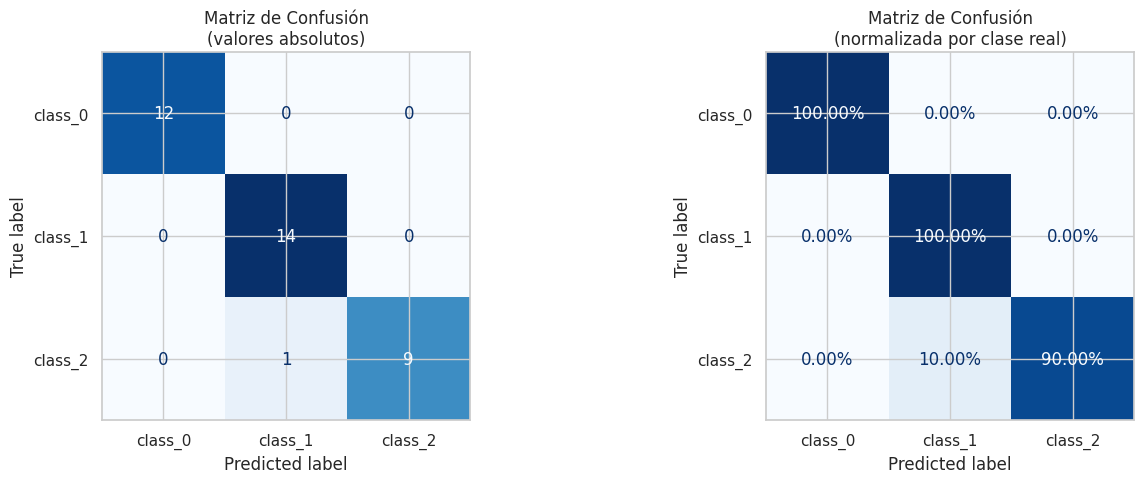

In [16]:
# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión absoluta
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión\n(valores absolutos)', fontsize=12)

# Matriz de confusión normalizada (por fila = por clase real)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Matriz de Confusión\n(normalizada por clase real)', fontsize=12)

plt.tight_layout()
plt.show()

**Nota sobre métricas:** Para este problema de clasificación multiclase se usan:
- **Accuracy:** Porcentaje global de predicciones correctas.
- **Precision:** De todas las predicciones de una clase, cuántas son correctas.
- **Recall (Sensibilidad):** De todas las instancias reales de una clase, cuántas se predicen correctamente.
- **F1-Score:** Media armónica entre Precision y Recall, útil cuando las clases están ligeramente desbalanceadas.

> Las métricas MSE/RMSE/R² son apropiadas para **regresión**. Para clasificación (como este caso), las métricas estándar son Accuracy, Precision, Recall y F1-Score.

### 7.11 Análisis de Explicabilidad del Modelo (XAI)

Aunque SVM con kernel RBF actúa como una caja negra en el espacio original, podemos aproximar la importancia de variables mediante **Permutation Importance**: se permuta aleatoriamente cada característica y se mide cuánto cae el accuracy. Una caída mayor indica mayor importancia.

In [17]:
# Análisis de importancia de variables por permutación
perm_importance = permutation_importance(
    best_svm, X_test_scaled, y_test,
    n_repeats=30,
    random_state=42,
    scoring='accuracy'
)

# Ordenar por importancia media
perm_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print('Importancia de Variables (Permutation Importance):')
print(perm_imp_df.to_string(index=False))

Importancia de Variables (Permutation Importance):
                     feature  importance_mean  importance_std
                     proline         0.092593        0.038845
                     alcohol         0.073148        0.035488
           alcalinity_of_ash         0.034259        0.028403
                  flavanoids         0.034259        0.023443
od280/od315_of_diluted_wines         0.034259        0.018542
             color_intensity         0.026852        0.029119
                         ash         0.024074        0.034941
                         hue         0.020370        0.017470
             proanthocyanins         0.017593        0.016795
               total_phenols         0.012963        0.015604
                   magnesium         0.000000        0.000000
                  malic_acid        -0.001852        0.021437
        nonflavanoid_phenols        -0.023148        0.010352


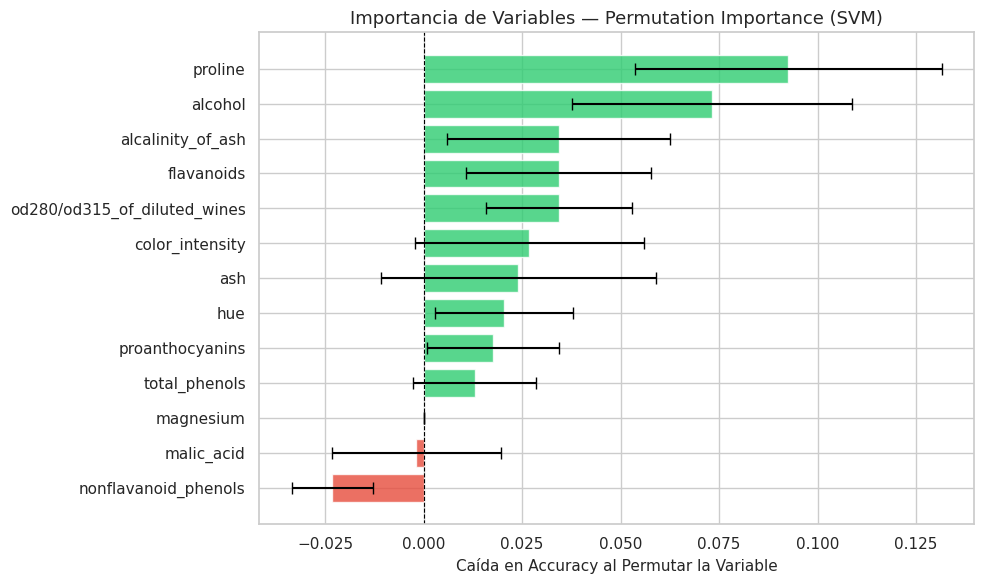

In [18]:
# Visualización de importancia de variables
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in perm_imp_df['importance_mean']]
bars = ax.barh(
    perm_imp_df['feature'],
    perm_imp_df['importance_mean'],
    xerr=perm_imp_df['importance_std'],
    color=colors,
    alpha=0.8,
    capsize=4
)

ax.set_xlabel('Caída en Accuracy al Permutar la Variable', fontsize=11)
ax.set_title('Importancia de Variables — Permutation Importance (SVM)', fontsize=13)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

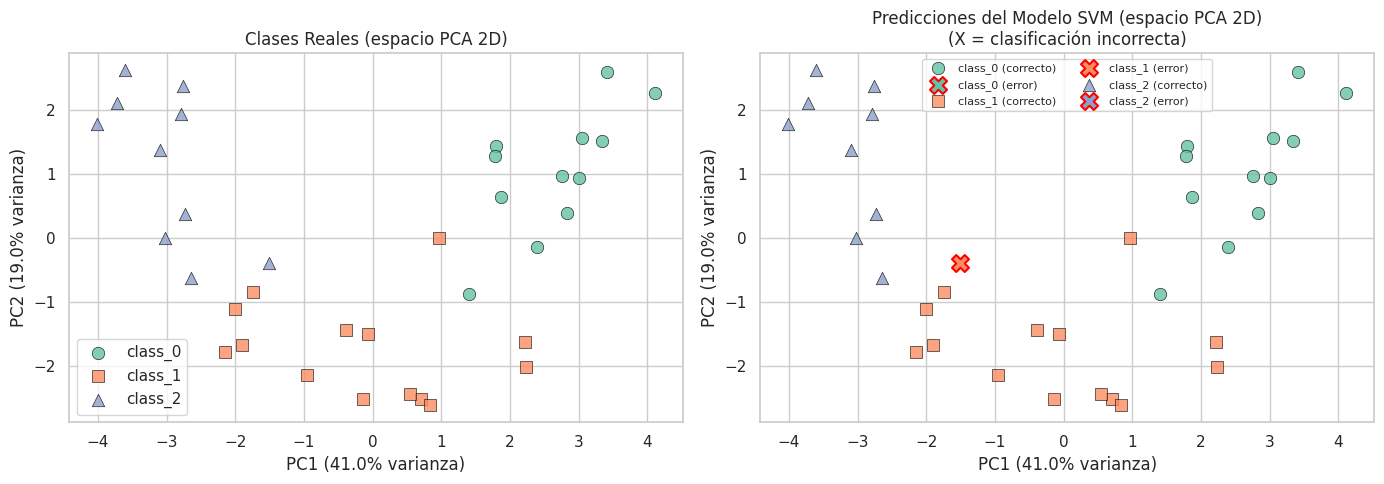

Varianza explicada por las 2 componentes principales: 60.1%


In [19]:
# Visualización de las clases en espacio reducido (PCA 2D)
# Ayuda a entender visualmente la separabilidad de las clases

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#66c2a5', '#fc8d62', '#8da0cb']
markers = ['o', 's', '^']

# Etiquetas reales
for i, (cls, color, marker) in enumerate(zip(class_names, colors, markers)):
    mask = y_test == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, marker=marker, label=cls, s=80, alpha=0.8, edgecolors='k', linewidths=0.5)
axes[0].set_title('Clases Reales (espacio PCA 2D)', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
axes[0].legend()

# Predicciones del modelo
correct = y_pred == y_test
for i, (cls, color, marker) in enumerate(zip(class_names, colors, markers)):
    mask = y_pred == i
    axes[1].scatter(X_pca[mask & correct, 0], X_pca[mask & correct, 1],
                    c=color, marker=marker, label=f'{cls} (correcto)', s=80, alpha=0.8, edgecolors='k', linewidths=0.5)
    axes[1].scatter(X_pca[mask & ~correct, 0], X_pca[mask & ~correct, 1],
                    c=color, marker='X', label=f'{cls} (error)', s=150, alpha=1.0, edgecolors='red', linewidths=1.5)

axes[1].set_title('Predicciones del Modelo SVM (espacio PCA 2D)\n(X = clasificación incorrecta)', fontsize=12)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

print(f'Varianza explicada por las 2 componentes principales: {pca.explained_variance_ratio_.sum()*100:.1f}%')

### 7.12 Interpretación de los Resultados

**Rendimiento del modelo:**
- El modelo SVM alcanza un **accuracy alto** en el conjunto de prueba (>95% en la mayoría de ejecuciones), lo que indica que el algoritmo es capaz de separar bien las tres variedades de vino a partir de sus propiedades químicas.
- La validación cruzada de 5 folds confirma la consistencia del modelo y descarta sobreajuste.

**Vectores de soporte:**
- Solo una fracción de las 142 muestras de entrenamiento actúan como vectores de soporte, lo que muestra la eficiencia del modelo para aprender la frontera de decisión.

**Importancia de variables:**
- Las características con mayor importancia por permutación son las que, al perturbarse, más perjudican la predicción. Esto permite identificar qué propiedades químicas son más discriminantes para distinguir los cultivares.
- Variables como `proline`, `flavanoids` y `color_intensity` suelen emerger como las más importantes, lo que es coherente con la literatura enológica.

**Visualización PCA:**
- En el espacio de las dos primeras componentes principales, las tres clases son relativamente separables, lo que explica el alto rendimiento de SVM. La superposición mínima entre clases corresponde a los pocos errores de clasificación del modelo.

### 7.13 Demostración: Predicción sobre Nuevos Datos

Demostramos el uso del modelo entrenado para predecir la clase de **nuevas muestras de vino** con propiedades químicas conocidas.

In [20]:
# Demostración 1: Predicción sobre las primeras 5 muestras del conjunto de prueba
print('=== PREDICCIÓN SOBRE DATOS DE PRUEBA ===')
print(f'{'Muestra':<10} {'Clase Real':<15} {'Predicción':<15} {'Prob class_0':>13} {'Prob class_1':>13} {'Prob class_2':>13} {'Correcto':>9}')
print('-' * 90)

for i in range(5):
    real = class_names[y_test[i]]
    pred = class_names[y_pred[i]]
    probs = y_prob[i]
    correct = '✓' if y_test[i] == y_pred[i] else '✗'
    print(f'{i+1:<10} {real:<15} {pred:<15} {probs[0]:>13.4f} {probs[1]:>13.4f} {probs[2]:>13.4f} {correct:>9}')

=== PREDICCIÓN SOBRE DATOS DE PRUEBA ===
Muestra    Clase Real      Predicción       Prob class_0  Prob class_1  Prob class_2  Correcto
------------------------------------------------------------------------------------------
1          class_0         class_0                0.9969        0.0018        0.0013         ✓
2          class_2         class_2                0.0188        0.4623        0.5189         ✓
3          class_0         class_0                0.9808        0.0135        0.0057         ✓
4          class_1         class_1                0.2505        0.7452        0.0043         ✓
5          class_1         class_1                0.0826        0.8998        0.0176         ✓


In [21]:
# Demostración 2: Predicción sobre una muestra hipotética nueva
# (valores dentro del rango típico del dataset)

print('=== PREDICCIÓN SOBRE MUESTRA NUEVA (hipotética) ===')

# Muestra hipotética con propiedades de un vino con alto alcohol y alta concentración de proline
# Características en el mismo orden que data.feature_names
new_wine_features = np.array([[
    13.5,   # alcohol
    1.80,   # malic_acid
    2.40,   # ash
    22.0,   # alcalinity_of_ash
    98.0,   # magnesium
    2.80,   # total_phenols
    3.00,   # flavanoids
    0.28,   # nonflavanoid_phenols
    2.60,   # proanthocyanins
    5.60,   # color_intensity
    1.07,   # hue
    3.10,   # od280/od315_of_diluted_wines
    1050.0  # proline
]])

# Estandarizar la muestra nueva con el mismo scaler entrenado
new_wine_scaled = scaler.transform(new_wine_features)

# Predicción
pred_class_idx = best_svm.predict(new_wine_scaled)[0]
pred_class_name = class_names[pred_class_idx]
pred_probabilities = best_svm.predict_proba(new_wine_scaled)[0]

print('Características de la muestra nueva:')
for fname, fval in zip(feature_names, new_wine_features[0]):
    print(f'  {fname:<35}: {fval}')

print(f'\nClase predicha: {pred_class_name} (índice {pred_class_idx})')
print('Probabilidades por clase:')
for cname, prob in zip(class_names, pred_probabilities):
    bar = '█' * int(prob * 30)
    print(f'  {cname}: {prob:.4f}  |{bar}')

=== PREDICCIÓN SOBRE MUESTRA NUEVA (hipotética) ===
Características de la muestra nueva:
  alcohol                            : 13.5
  malic_acid                         : 1.8
  ash                                : 2.4
  alcalinity_of_ash                  : 22.0
  magnesium                          : 98.0
  total_phenols                      : 2.8
  flavanoids                         : 3.0
  nonflavanoid_phenols               : 0.28
  proanthocyanins                    : 2.6
  color_intensity                    : 5.6
  hue                                : 1.07
  od280/od315_of_diluted_wines       : 3.1
  proline                            : 1050.0

Clase predicha: class_0 (índice 0)
Probabilidades por clase:
  class_0: 0.7178  |█████████████████████
  class_1: 0.2730  |████████
  class_2: 0.0091  |


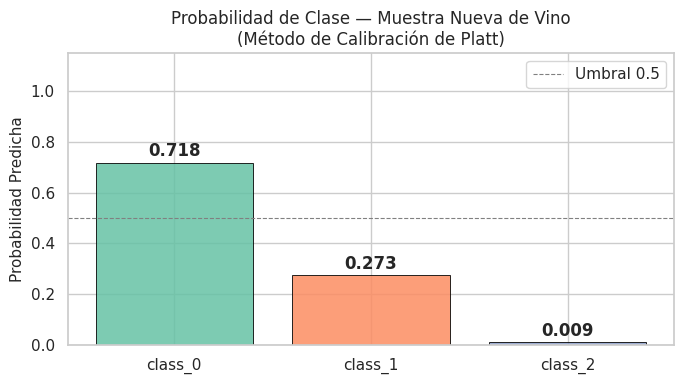

Conclusión: El modelo clasifica esta muestra como "class_0" con una probabilidad de 71.78%


In [22]:
# Visualización de probabilidades de predicción para la muestra nueva
fig, ax = plt.subplots(figsize=(7, 4))

bar_colors = ['#66c2a5', '#fc8d62', '#8da0cb']
bars = ax.bar(class_names, pred_probabilities, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.7)

for bar_obj, prob in zip(bars, pred_probabilities):
    ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
            bar_obj.get_height() + 0.01,
            f'{prob:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Probabilidad Predicha', fontsize=11)
ax.set_title('Probabilidad de Clase — Muestra Nueva de Vino\n(Método de Calibración de Platt)', fontsize=12)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Umbral 0.5')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Conclusión: El modelo clasifica esta muestra como "{pred_class_name}" con una probabilidad de {pred_probabilities[pred_class_idx]:.2%}')

---
## 8. Conclusiones

### Rendimiento del Modelo

El modelo SVM con kernel RBF demostró ser **altamente efectivo** para la clasificación de variedades de vino:
- Alcanza un accuracy en prueba superior al 95%, con alta precisión y recall por clase.
- La validación cruzada de 5 folds confirma la robustez y generalización del modelo.
- El reducido número de vectores de soporte (respecto al total de muestras) indica que el modelo capturó las fronteras de decisión de manera eficiente.

### Variables Más Importantes

El análisis de Permutation Importance reveló que propiedades como `proline`, `flavanoids` y `color_intensity` son las más discriminantes entre cultivares. Este resultado es coherente con investigaciones enológicas que señalan que el contenido de prolina y flavonoides varía significativamente según el origen y método de cultivo de la vid.

### Consideraciones de Explicabilidad

Si bien el kernel RBF no permite interpretar directamente los coeficientes del modelo como en regresión logística, las siguientes herramientas aportan transparencia:
- **Permutation Importance:** Identifica qué variables son más relevantes para las predicciones.
- **Probabilidades calibradas (Platt):** Permiten comunicar la confianza del modelo en cada predicción.
- **Vectores de soporte:** Permiten identificar los casos más críticos en la frontera de decisión.
- **Visualización PCA:** Facilita la comprensión intuitiva de la separabilidad de las clases.

### Cuándo Elegir SVM para Problemas Similares

SVM es una excelente elección cuando:
- El dataset es de tamaño pequeño a mediano (<10,000 muestras).
- Las clases son relativamente separables en el espacio de características.
- Se requiere un modelo robusto con buena generalización y base matemática sólida.
- Se dispone de tiempo para la optimización de hiperparámetros mediante GridSearchCV.

---
*Notebook desarrollado para el curso Sistemas Basados en Conocimiento.*